<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan2_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# NAMA  : SEPTIAN AL RIZKI
# NIM   : 230401010262
# KELAS : IF 401

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Memuat dataset (berjaga-jaga jika df sebelumnya terhapus)
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)

sns.set_theme(style='whitegrid', palette='pastel')

In [46]:
#1. Berapa jumlah baris dan kolom pada dataset Titanic? Kolom apa saja yang tersedia?
print("=== LANGKAH 1: KESELAMATAN KESELURUHAN ===")
survived_counts = df['Survived'].value_counts()
print(f"Tidak Selamat (0) : {survived_counts[0]} orang")
print(f"Selamat (1)       : {survived_counts[1]} orang")
print("-" * 50)

=== LANGKAH 1: KESELAMATAN KESELURUHAN ===
Tidak Selamat (0) : 549 orang
Selamat (1)       : 342 orang
--------------------------------------------------


In [47]:
# 2. Kolom mana saja yang memiliki missing values? Berapa jumlah dan proporsinya (%) per kolom?
print("=== LANGKAH 2: KESELAMATAN BERDASARKAN KELAS ===")
class_survival = (df.groupby('Pclass')['Survived'].mean() * 100).round(2)
print(class_survival.astype(str) + " %")
print("-" * 50)

=== LANGKAH 2: KESELAMATAN BERDASARKAN KELAS ===
Pclass
1    62.96 %
2    47.28 %
3    24.24 %
Name: Survived, dtype: object
--------------------------------------------------


Hasil : Data tersebut terdiri dari 819 Baris, dan 12 Kolom

In [48]:
# 3. Berapa persen penumpang yang selamat (Survived=1)? Gunakan operasi NumPy atau Pandas.
total_kosong = df.isnull().sum()

# Memfilter HANYA kolom yang memiliki nilai kosong (lebih dari 0)
kolom_kosong = total_kosong[total_kosong > 0]

# Menghitung persentase dari total baris (len(df))
persentase_kosong = (kolom_kosong / len(df)) * 100

# Menggabungkan hasil ke dalam tabel (DataFrame) agar rapi
df_missing_info = pd.DataFrame({
    'Total Kosong': kolom_kosong,
    'Persentase (%)': persentase_kosong.round(2) # round(2) untuk membulatkan 2 desimal
})

# Mengurutkan dari persentase yang paling besar ke kecil
df_missing_info = df_missing_info.sort_values(by='Persentase (%)', ascending=False)

# Menampilkan hasil
print(f"Ditemukan {len(df_missing_info)} kolom yang memiliki nilai kosong:\n")
print(df_missing_info)

Ditemukan 3 kolom yang memiliki nilai kosong:

          Total Kosong  Persentase (%)
Cabin              687           77.10
Age                177           19.87
Embarked             2            0.22


Hasil : Data yang Kosong yaitu Cabin(77.10%), Age(19.87), Embarked (0.22).

In [49]:
#4. Filter penumpang wanita dari kelas 1 (Pclass=1). Berapa jumlahnya dan berapa ratarata usianya?
print("=== LANGKAH 4: KESELAMATAN BERDASARKAN USIA ===")
# Membuat pengelompokan usia: 0-12 (Anak), 13-59 (Dewasa), 60+ (Lansia)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 59, 100], labels=['Anak-anak (0-12)', 'Dewasa (13-59)', 'Lansia (60+)'])
age_survival = (df.groupby('AgeGroup')['Survived'].mean() * 100).round(2)
print(age_survival.astype(str) + " %")
print("-" * 50)

=== LANGKAH 4: KESELAMATAN BERDASARKAN USIA ===
AgeGroup
Anak-anak (0-12)    57.97 %
Dewasa (13-59)      39.26 %
Lansia (60+)        26.92 %
Name: Survived, dtype: object
--------------------------------------------------


/tmp/ipykernel_7579/751997955.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = (df.groupby('AgeGroup')['Survived'].mean() * 100).round(2)


Hasil : Persentase Penumpang Selamat: 38.38%

In [50]:
#5. Gunakan groupby untuk menghitung tingkat keselamatan (mean Survived) per kelas penumpang. Kelas mana yang paling tinggi?
# Memfilter wanita di Pclass 1
wk1 = df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]

# Print harus di baris baru
print("Persentase Selamat (Wanita Kelas 1):", wk1['Survived'].mean() * 100, "%")
print("Rata-rata Umur (Wanita Kelas 1):", wk1['Age'].mean(), "tahun")

Persentase Selamat (Wanita Kelas 1): 96.80851063829788 %
Rata-rata Umur (Wanita Kelas 1): 34.61176470588235 tahun


Hasil : Rata-rata usia Penumpang Kelas 1 ( 34.61 Tahun )

=== LANGKAH 5: MEMUAT VISUALISASI GRAFIK ===


/tmp/ipykernel_7579/3513244722.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_survival.index, y=class_survival.values, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_7579/3513244722.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_survival.index, y=sex_survival.values, ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_7579/3513244722.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_survival.index, y=age_survival.values, ax=axes[1, 1], palette='coolwarm')


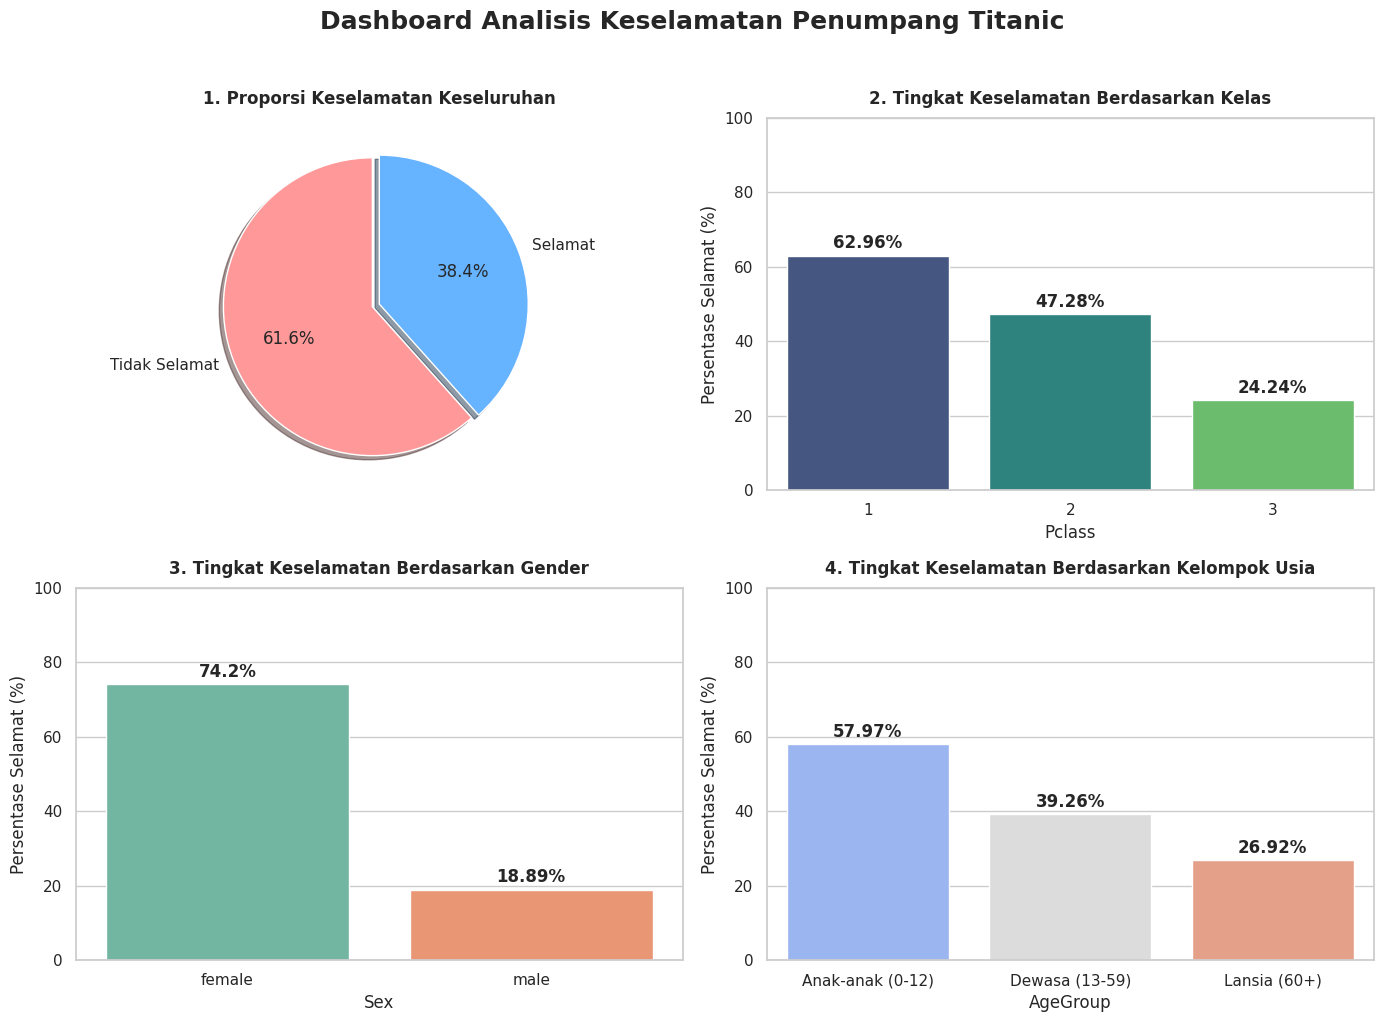

In [51]:
#6. Buat analisis tambahan berdasarkan variabel lain yang Anda anggap menarik. Sertakan interpretasi singkat.
print("=== LANGKAH 5: MEMUAT VISUALISASI GRAFIK ===")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Analisis Keselamatan Penumpang Titanic', fontsize=18, fontweight='bold', y=1.02)

# Plot 1: Overall Survival (Pie Chart)
axes[0, 0].pie(survived_counts, labels=['Tidak Selamat', 'Selamat'], autopct='%1.1f%%',
               colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0), shadow=True)
axes[0, 0].set_title('1. Proporsi Keselamatan Keseluruhan', fontweight='bold', pad=10)

# Plot 2: Survival by Class (Bar Chart)
sns.barplot(x=class_survival.index, y=class_survival.values, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('2. Tingkat Keselamatan Berdasarkan Kelas', fontweight='bold', pad=10)
axes[0, 1].set_ylabel('Persentase Selamat (%)')
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(class_survival.values):
    axes[0, 1].text(i, v + 2, f"{v}%", ha='center', fontweight='bold')

# Plot 3: Survival by Gender (Bar Chart)
sns.barplot(x=sex_survival.index, y=sex_survival.values, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Tingkat Keselamatan Berdasarkan Gender', fontweight='bold', pad=10)
axes[1, 0].set_ylabel('Persentase Selamat (%)')
axes[1, 0].set_ylim(0, 100)
for i, v in enumerate(sex_survival.values):
    axes[1, 0].text(i, v + 2, f"{v}%", ha='center', fontweight='bold')

# Plot 4: Survival by Age Group (Bar Chart)
sns.barplot(x=age_survival.index, y=age_survival.values, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('4. Tingkat Keselamatan Berdasarkan Kelompok Usia', fontweight='bold', pad=10)
axes[1, 1].set_ylabel('Persentase Selamat (%)')
axes[1, 1].set_ylim(0, 100)
for i, v in enumerate(age_survival.values):
    # Menambahkan pengecekan agar tidak error jika ada NaN
    if not np.isnan(v):
        axes[1, 1].text(i, v + 2, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Narasi Interpretasi :
1.   Grafik 1 (Proporsi Keselamatan Total):
Interpretasi: Tragedi Titanic memakan banyak korban. Dari total data, sebanyak 61,6% penumpang tidak selamat, dan hanya 38,4% yang berhasil diselamatkan.
2.   Grafik 2 (Berdasarkan Kelas):
Interpretasi: Terdapat ketimpangan sosial yang jelas. Penumpang Kelas 1 memiliki peluang hidup tertinggi (~63%), sedangkan penumpang Kelas 3 memiliki peluang hidup terendah (~24%). Posisi kabin dan akses ke sekoci sangat dipengaruhi oleh kelas tiket.
3.   Grafik 3 (Berdasarkan Jenis Kelamin):
Interpretasi: Hukum laut "Women and Children First" (Wanita dan Anak-anak terlebih dahulu) benar-benar diterapkan. Terlihat bahwa peluang selamat Wanita (~74%) jauh melampaui Pria yang hanya sekitar 18%.
4.   Grafik 4 (Berdasarkan Kelompok Usia):
Interpretasi: Memperkuat argumen sebelumnya, Anak-anak (usia 0-12 tahun) adalah kelompok usia yang paling diprioritaskan dengan tingkat keselamatan tertinggi (~58%), dibandingkan orang dewasa (~38%) dan kelompok lansia yang paling rentan (~26%).


